# Численная часть

In [20]:
import os

import numpy as np
import matplotlib.pyplot as plt

plt.style.use('default')
IMAGES_DIR = "images"
os.makedirs(IMAGES_DIR, exist_ok=True)

N_VALUES = [3, 5, 10, 30, 69, 1337]

## Коэффициенты общего тригонометрического ряда Фурье

In [21]:
def a_common(k):
    return (
        2 * np.pi * k * np.sin(4 * np.pi * k / 3)
        + 3 * np.cos(4 * np.pi * k / 3)
        - 3
    ) / (2 * np.pi ** 2 * k ** 2)


def b_common(k):
    return (
        np.pi * k * (2 - np.cos(4 * np.pi * k / 3))
        + 3 * np.sin(4 * np.pi * k / 3) / 2
    ) / (np.pi ** 2 * k ** 2)

## Коэффициенты ряда Фурье по косинусам

In [22]:
def a_cos(k):
    return (
        2 * np.pi * k * np.sin(2 * np.pi * k / 3)
        + 6 * np.cos(2 * np.pi * k / 3)
        - 6 * (-1) ** k
    ) / (np.pi ** 2 * k ** 2)

## Коэффициенты ряда Фурье по синусам

In [23]:
def b_sin(k):
    return (
        2 * np.pi * k * (1 - np.cos(2 * np.pi * k / 3) + (-1) ** k)
        + 6 * np.sin(2 * np.pi * k / 3)
    ) / (np.pi ** 2 * k ** 2)

## Частичные суммы рядов Фурье

In [24]:
def common_sum(x, n):
    result = np.full_like(x, 1 / 2, dtype=float)

    for k in range(1, n + 1):
        result += (
            a_common(k) * np.cos(2 * np.pi * k * x / 3)
            + b_common(k) * np.sin(2 * np.pi * k * x / 3)
        )

    return result


def cos_sum(x, n):
    result = np.full_like(x, 1 / 2, dtype=float)

    for k in range(1, n + 1):
        result += a_cos(k) * np.cos(np.pi * k * x / 3)

    return result


def sin_sum(x, n):
    result = np.zeros_like(x, dtype=float)

    for k in range(1, n + 1):
        result += b_sin(k) * np.sin(np.pi * k * x / 3)

    return result

## Суммы рядов

In [25]:
def f_common(x):
    r = x - 3 * np.floor(x / 3)

    return np.where(r < 2, 1, 2 - r)


def f_even(x):
    u = x - 6 * np.floor((x + 3) / 6)
    q = np.abs(u)

    return np.where(q < 2, 1, 2 - q)


def f_odd(x):
    u = x - 6 * np.floor((x + 3) / 6)

    result = np.zeros_like(x, dtype=float)

    result = np.where((-3 < u) & (u < -2), -2 - u, result)
    result = np.where((-2 < u) & (u < 0), -1, result)
    result = np.where((0 < u) & (u < 2), 1, result)
    result = np.where((2 < u) & (u < 3), 2 - u, result)

    return result

## Рендер графиков

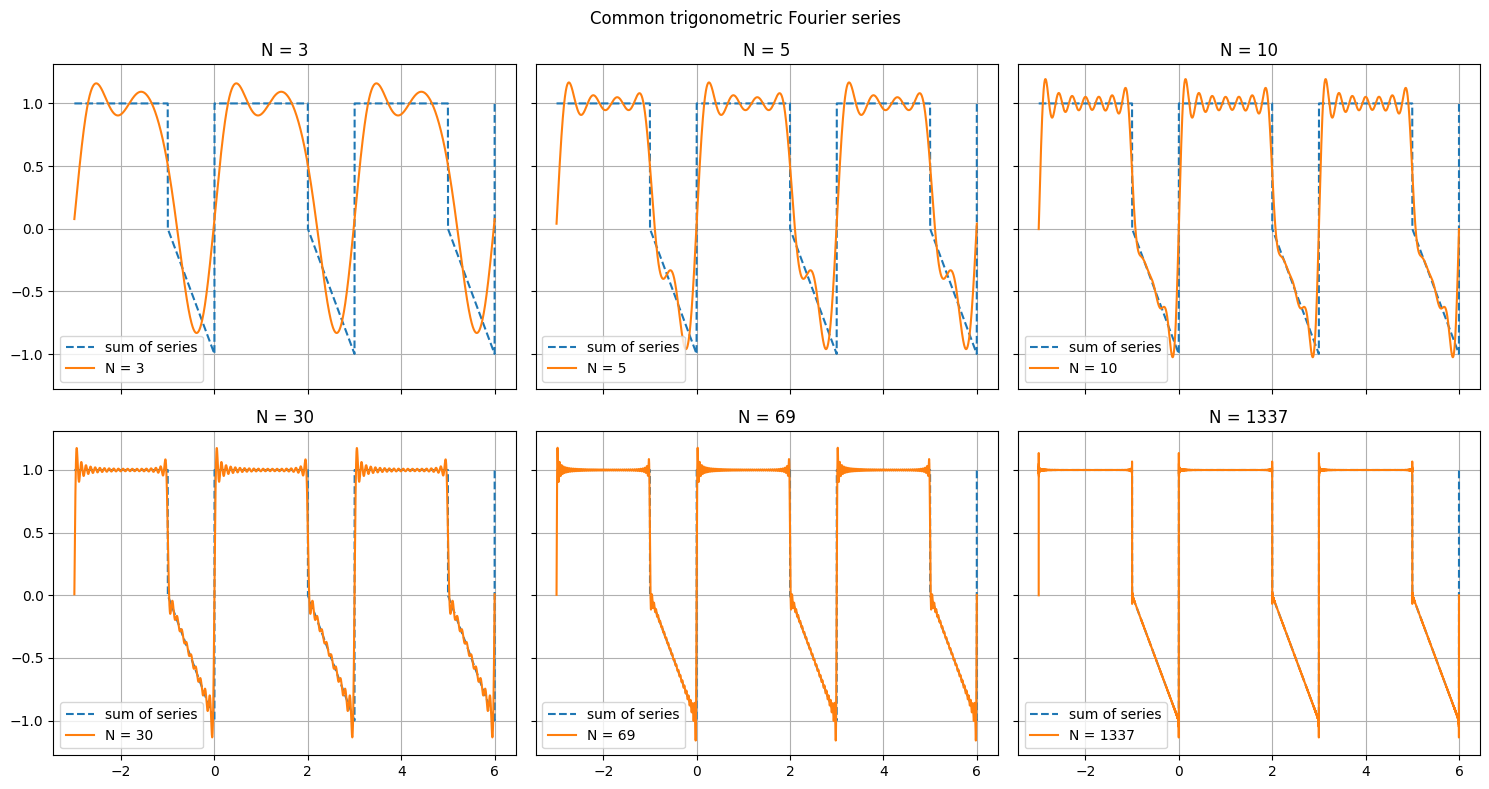

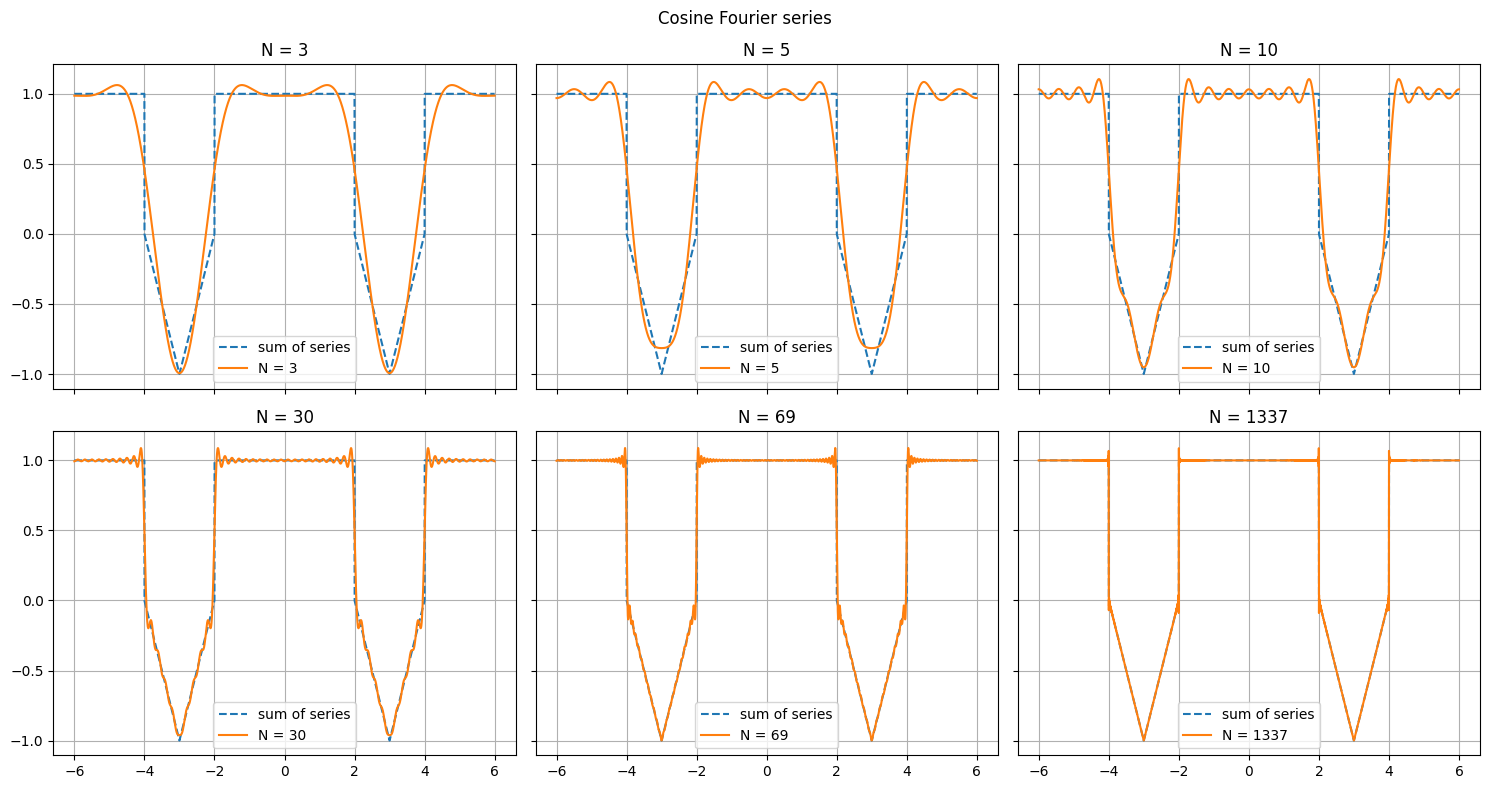

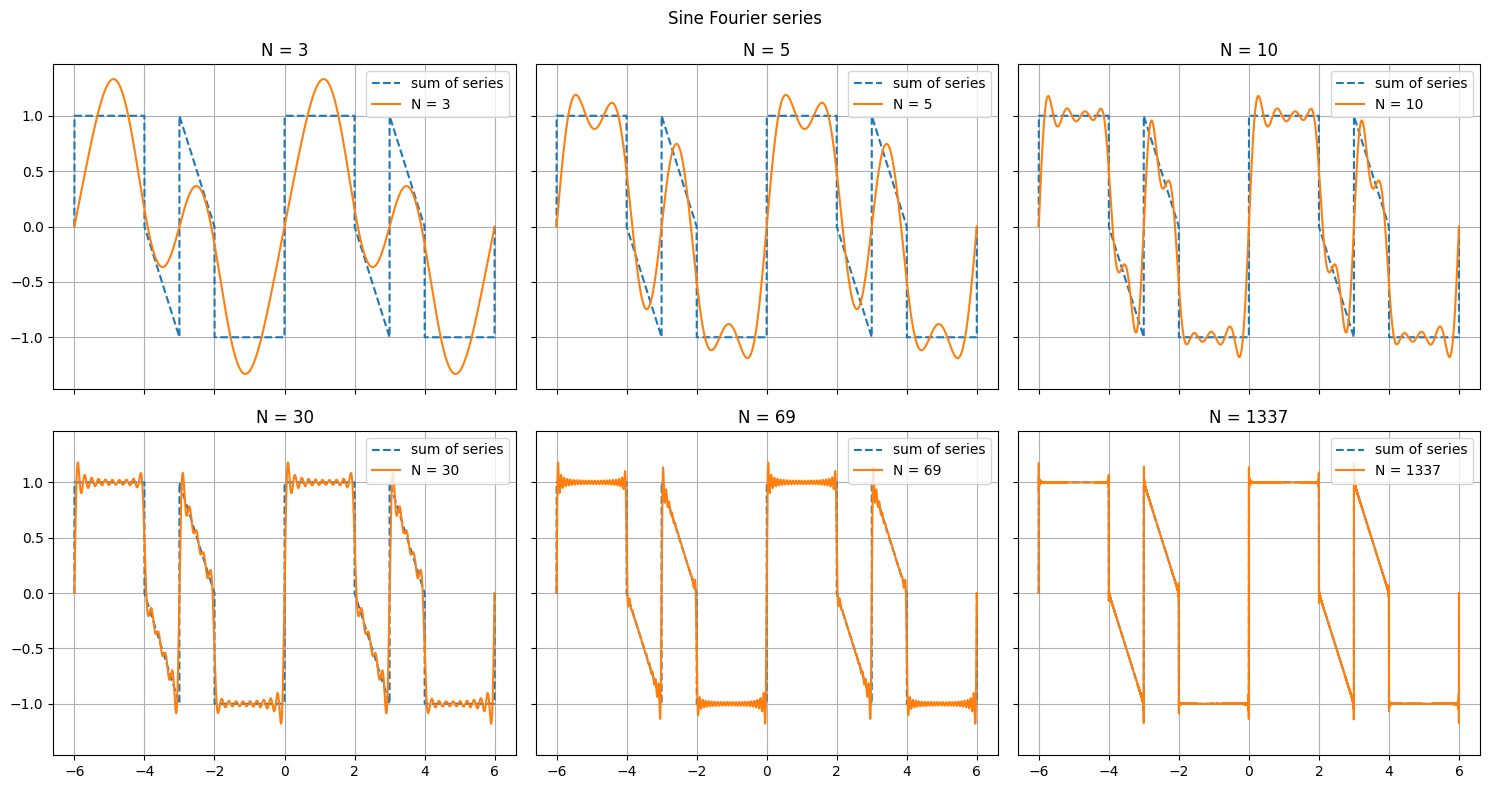

In [26]:
def render_group(x, exact_function, partial_function, title, filename):
    fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True, sharey=True)
    axes = axes.ravel()

    exact = exact_function(x)

    for ax, n in zip(axes, N_VALUES):
        ax.plot(x, exact, "--", label="sum of series")
        ax.plot(x, partial_function(x, n), label=f"N = {n}")
        ax.set_title(f"N = {n}")
        ax.grid(True)
        ax.legend()

    fig.suptitle(title)
    fig.tight_layout()

    path = os.path.join(IMAGES_DIR, filename)
    fig.savefig(path)
    plt.show()

    return path

x_common = np.linspace(-3, 6, 10000)
x_half = np.linspace(-6, 6, 10000)

for name, x, exact_function, partial_function, title in [
    (
        "common.png",
        x_common,
        f_common,
        common_sum,
        "Common trigonometric Fourier series"
    ),
    (
        "cos.png",
        x_half,
        f_even,
        cos_sum,
        "Cosine Fourier series"
    ),
    (
        "sin.png",
        x_half,
        f_odd,
        sin_sum,
        "Sine Fourier series"
    )
]:
    render_group(x, exact_function, partial_function, title, name)